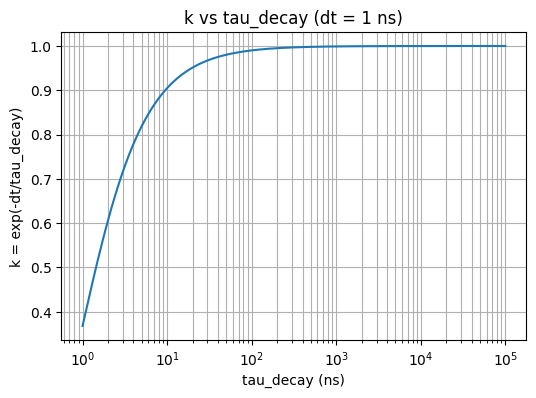

In [2]:
import numpy as np
import matplotlib.pyplot as plt

dt = 1e-9  # 1 ns 采样
tau_list = np.logspace(-9, -4, 400)  # 1 ns 到 100 us
k_list = np.exp(-dt / tau_list)

plt.figure(figsize=(6,4))
plt.semilogx(tau_list*1e9, k_list)
plt.xlabel("tau_decay (ns)")
plt.ylabel("k = exp(-dt/tau_decay)")
plt.title("k vs tau_decay (dt = 1 ns)")
plt.grid(True, which="both")
plt.show()


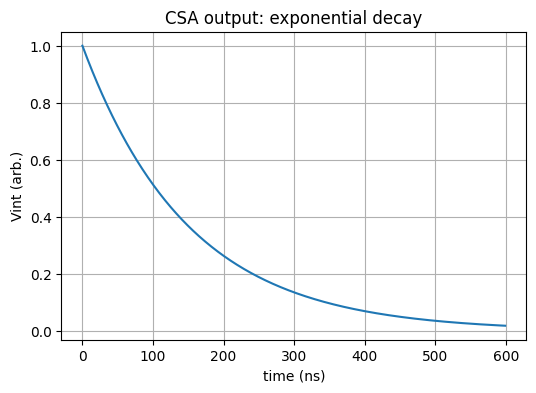

In [3]:
dt = 1e-9
tau_decay = 150e-9   # 150 ns
t = np.arange(0, 600e-9, dt)

# 假设 CSA 阶跃幅度 = 1
Vint = np.exp(-t / tau_decay)

plt.figure(figsize=(6,4))
plt.plot(t*1e9, Vint)
plt.xlabel("time (ns)")
plt.ylabel("Vint (arb.)")
plt.title("CSA output: exponential decay")
plt.grid(True)
plt.show()


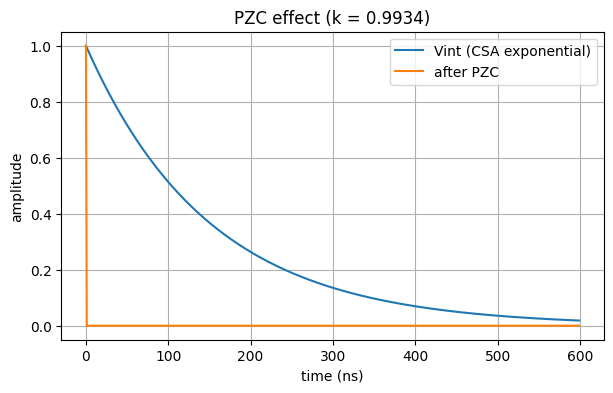

In [4]:
def pzc_from_vint(vint, dt, tau_decay):
    k = np.exp(-dt / tau_decay)
    v_pz = np.zeros_like(vint)
    v_pz[0] = vint[0]
    for n in range(1, len(vint)):
        v_pz[n] = vint[n] - k * vint[n-1]
    return v_pz, k

v_pz, k_used = pzc_from_vint(Vint, dt, tau_decay)

plt.figure(figsize=(7,4))
plt.plot(t*1e9, Vint, label="Vint (CSA exponential)")
plt.plot(t*1e9, v_pz, label="after PZC")
plt.xlabel("time (ns)")
plt.ylabel("amplitude")
plt.title(f"PZC effect (k = {k_used:.4f})")
plt.legend()
plt.grid(True)
plt.show()


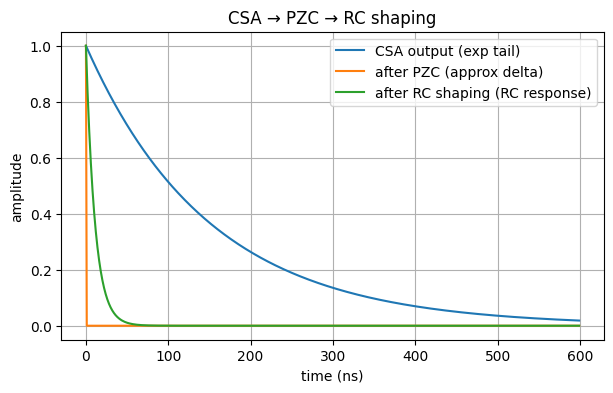

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def pzc_from_vint(vint, dt, tau_decay):
    k = np.exp(-dt / tau_decay)
    v_pz = np.zeros_like(vint, dtype=float)
    v_pz[0] = vint[0]
    for n in range(1, len(vint)):
        v_pz[n] = vint[n] - k * vint[n-1]
    return v_pz

def rc_filter(x, dt, tau_rc):
    """一阶 RC 低通的离散递推：必须把 x[0] 注入到 y[0]"""
    a = np.exp(-dt / tau_rc)
    y = np.zeros_like(x, dtype=float)
    y[0] = x[0]  # 关键：不然 δ[n] 会被漏掉
    for n in range(1, len(x)):
        y[n] = a * y[n-1] + (1 - a) * x[n]
    return y

# ====== 参数 ======
dt = 1e-9
tau_decay = 150e-9
tau_rc = 11e-9
T = 600e-9
n = int(T/dt) + 1

t = np.arange(n) * dt

# ====== 构造一个“单位电荷事件”的 CSA 输出（指数衰减尾巴） ======
Vint = np.exp(-t / tau_decay)  # Vint[0]=1, 后面指数衰减

# ====== PZC：打掉 CSA 极点（得到近似 δ） ======
v_pz = pzc_from_vint(Vint, dt, tau_decay)

# ====== RC shaping：对 δ 做一阶 RC 响应 ======
y = rc_filter(v_pz, dt, tau_rc)

# ====== 画图 ======
plt.figure(figsize=(7,4))
plt.plot(t*1e9, Vint, label="CSA output (exp tail)")
plt.plot(t*1e9, v_pz, label="after PZC (approx delta)")
plt.plot(t*1e9, y, label="after RC shaping (RC response)")
plt.xlabel("time (ns)")
plt.ylabel("amplitude")
plt.title("CSA → PZC → RC shaping")
plt.legend()
plt.grid(True)
plt.show()
